# Part 01: Nyquist frequency and rate
It is said that birds may sing with a frequency up to 8 kHz.
What is the Nyquist frequency and the Nyquist rate for sampling such a bird song.

Nyquist Sampling Rate = double the maximum frequency => 16kHz

If we assume that we sample with 16kHz, then the Nyquist frequency (maximum frequency we can caputre) would be 8kHz.

---

# Part 02: Data of digitalized sounds
a) Given the results of part 01, calculate the amount of data generated for a 1 minute recording of a birds song. The sound shall be recorded mono (1 channel) with 1 Byte per sample.  
b) If MP3 can achieve a compression rate of 75% and 30 minutes are saved in a MP3 file. How big is the
file?

a) 1Hz = 1 Sample Point per Second

  60s * 16.000 1/s * 1 Byte
= 960.000 Byte
= 0.96 MB

b)
  30 * 60s * 16.000 1/s * 1 Byte * 0.75
= 21.6 MB

---

# Part 03: MFCC
Visit the website https://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html
(vivited 24/04/05) and work through the description. Especially, find out the x- and y- axes of the diagrams:  
• Waveform  
• Spectrum / Mel-scale spectrum  
• Spectrogram  
• MFCC diagram  
If you want, you may test and update the used Python code.

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time_domain(signal, sample_rate, title="Signal in the Time Domain"):
    """Recreates the time-domain signal plots (Blue line, dashed grid)."""
    time = np.linspace(0, len(signal) / sample_rate, num=len(signal))
    plt.figure(figsize=(12, 4))
    plt.plot(time, signal, color='blue', linewidth=1)
    plt.title(title, y=-0.25)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(0, time[-1])
    plt.tight_layout()
    plt.show()

def plot_hamming_window(window_func):
    """Plots the Hamming window shape (Amplitude vs Samples)."""
    plt.figure(figsize=(8, 4))
    plt.plot(window_func, color='blue', linewidth=1, label='Hamming')
    plt.title('Hamming Window', y=-0.25)
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_mel_filter_banks(fbank, sample_rate):
    """Plots the triangular filter banks across the frequency spectrum."""
    plt.figure(figsize=(12, 4))
    # Frequency axis up to Nyquist (sample_rate / 2)
    freq_axis = np.linspace(0, sample_rate / 2, fbank.shape[1])
    for i in range(len(fbank)):
        plt.plot(freq_axis, fbank[i])
    plt.title('Filter bank on a Mel-Scale', y=-0.25)
    plt.xlabel('Frequency')
    plt.ylabel('Amplitude')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_spectrogram(data, sample_rate, title="Spectrogram of the Signal", is_mfcc=False):
    """
    Plots heatmaps for Filter Banks or MFCCs.
    Matches the 'jet' colormap and axis orientation seen in the tutorial.
    """
    plt.figure(figsize=(12, 4))
    # Transpose data because tutorial logic usually outputs [frames, coefficients]
    # Heatmap needs [y_axis, x_axis]
    extent = [0, 3.5, 0, (sample_rate / 2) / 1000 if not is_mfcc else data.shape[1]]
    
    plt.imshow(data.T, aspect='auto', origin='lower', 
               cmap='jet', extent=extent)
    
    plt.title(title, y=-0.25)
    plt.xlabel('Time (s)')
    
    if is_mfcc:
        plt.ylabel('MFCC Coefficients')
    else:
        plt.ylabel('Frequency (kHz)')
        
    plt.tight_layout()
    plt.show()

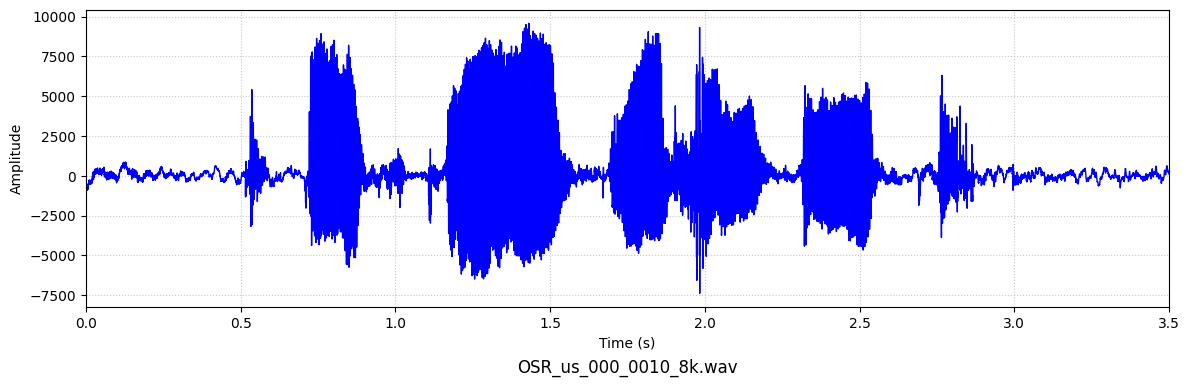

In [69]:
import scipy.io.wavfile
from scipy.fftpack import dct

sample_rate, signal = scipy.io.wavfile.read('OSR_us_000_0010_8k.wav')  # File assumed to be in the same directory
signal = signal[0:int(3.5 * sample_rate)]  # Keep the first 3.5 seconds

plot_time_domain(signal, sample_rate, 'OSR_us_000_0010_8k.wav')

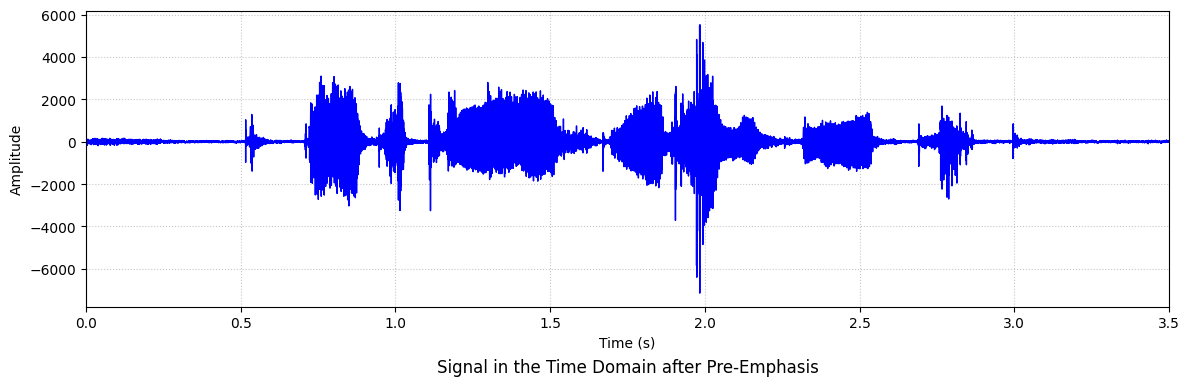

In [70]:
pre_emphasis = 0.97
emphasized_signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

plot_time_domain(emphasized_signal, sample_rate, 'Signal in the Time Domain after Pre-Emphasis')

In [71]:
frame_size = 0.025
frame_stride = 0.01

frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate  # Convert from seconds to samples
signal_length = len(emphasized_signal)
frame_length = int(round(frame_length))
frame_step = int(round(frame_step))
num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))  # Make sure that we have at least 1 frame

pad_signal_length = num_frames * frame_step + frame_length
z = np.zeros((pad_signal_length - signal_length))
pad_signal = np.append(emphasized_signal, z) # Pad Signal to make sure that all frames have equal number of samples without truncating any samples from the original signal

indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
frames = pad_signal[indices.astype(np.int32, copy=False)]

frames *= np.hamming(frame_length)
# frames *= 0.54 - 0.46 * np.cos((2 * numpy.pi * n) / (frame_length - 1))  # Explicit Implementation **

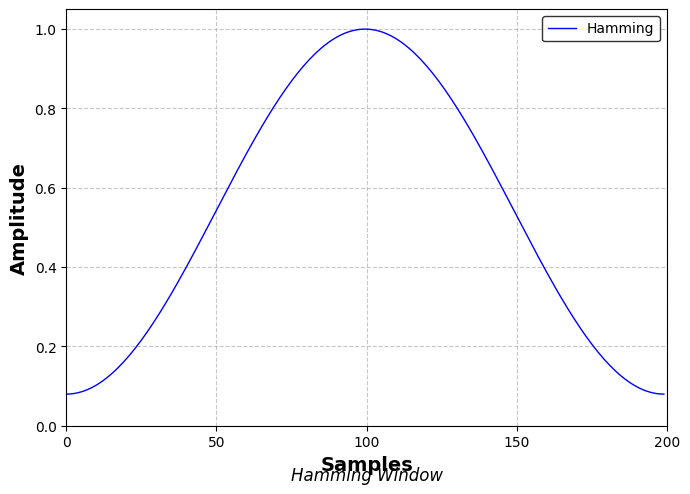

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the parameters
N = 200  # Based on the x-axis of the image
n = np.arange(N)

# 2. Generate the Hamming window using the formula from the article
# This is equivalent to np.hamming(N)
hamming_window = 0.54 - 0.46 * np.cos((2 * np.pi * n) / (N - 1))

# 3. Create the plot
plt.figure(figsize=(7, 5))
plt.plot(n, hamming_window, color='blue', label='Hamming', linewidth=1)

# Style adjustments to match the article
plt.title('Hamming Window', y=-0.15, fontsize=12, style='italic') # Caption style
plt.xlabel('Samples', fontsize=14, fontweight='bold')
plt.ylabel('Amplitude', fontsize=14, fontweight='bold')

# Set Axis Limits and Ticks
plt.xlim(0, 200)
plt.ylim(0, 1.05)
plt.xticks([0, 50, 100, 150, 200])
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

In [73]:
NFFT = 512

mag_frames = np.absolute(np.fft.rfft(frames, NFFT))  # Magnitude of the FFT
pow_frames = ((1.0 / NFFT) * ((mag_frames) ** 2))  # Power Spectrum

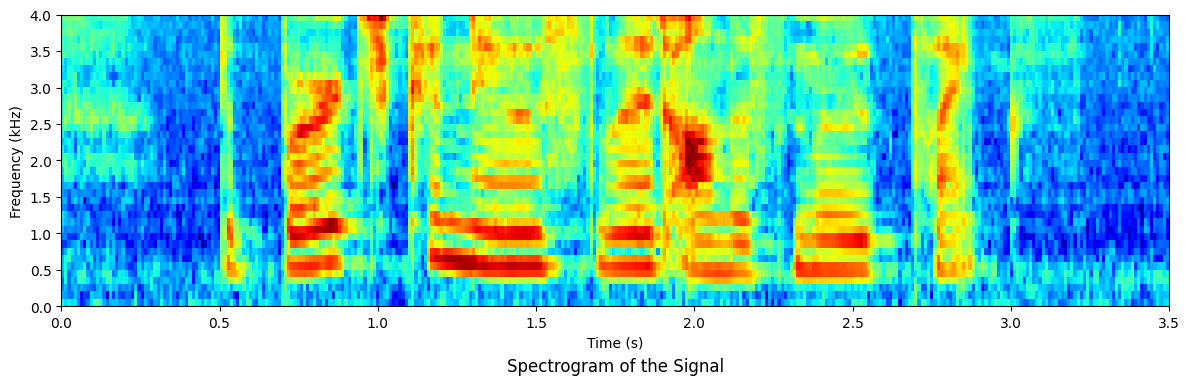

In [74]:
nfilt = 40

low_freq_mel = 0
high_freq_mel = (2595 * np.log10(1 + (sample_rate / 2) / 700))  # Convert Hz to Mel
mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2)  # Equally spaced in Mel scale
hz_points = (700 * (10**(mel_points / 2595) - 1))  # Convert Mel to Hz
bin = np.floor((NFFT + 1) * hz_points / sample_rate)

fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
for m in range(1, nfilt + 1):
    f_m_minus = int(bin[m - 1])   # left
    f_m = int(bin[m])             # center
    f_m_plus = int(bin[m + 1])    # right

    for k in range(f_m_minus, f_m):
        fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
    for k in range(f_m, f_m_plus):
        fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])
filter_banks = np.dot(pow_frames, fbank.T)
filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)  # Numerical Stability
filter_banks = 20 * np.log10(filter_banks)  # dB

plot_spectrogram(filter_banks, sample_rate)

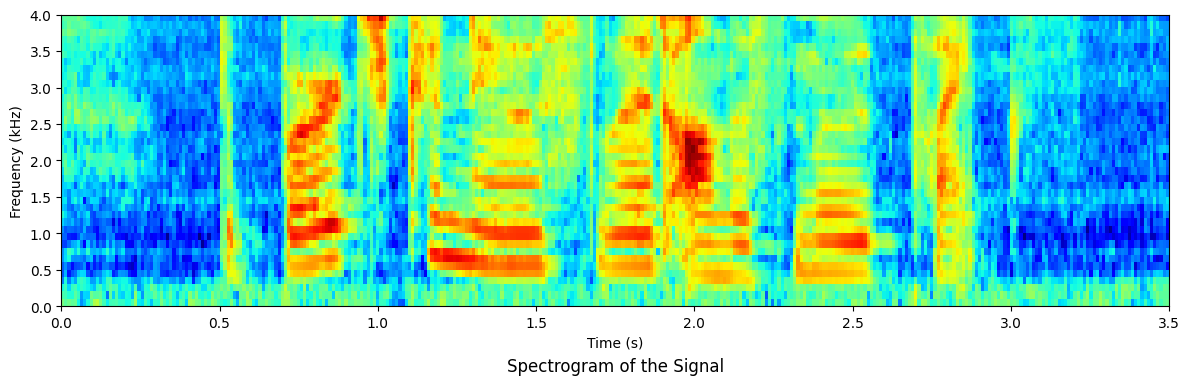

In [75]:
filter_banks -= (np.mean(filter_banks, axis=0) + 1e-8)
plot_spectrogram(filter_banks, sample_rate)

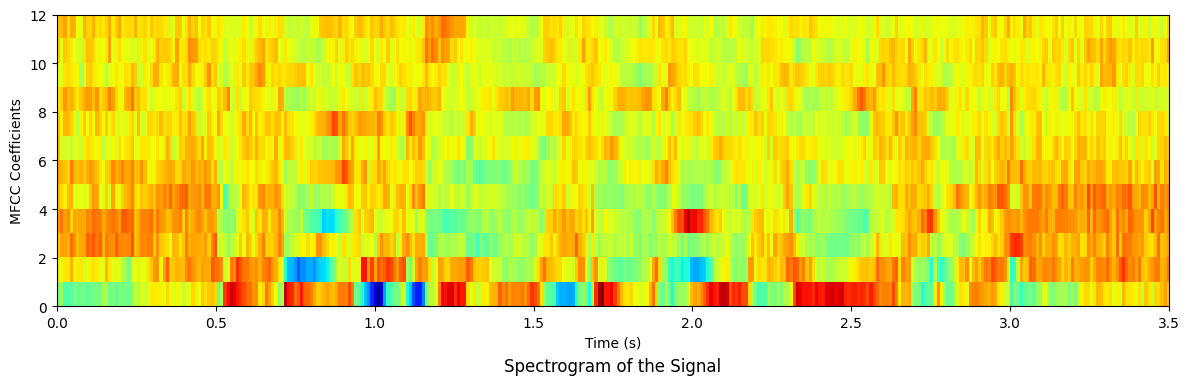

In [76]:
num_ceps = 12
mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)] # Keep 2-13
(nframes, ncoeff) = mfcc.shape
n = np.arange(ncoeff)
cep_lifter = 0
if cep_lifter > 0:
  lift = 1 + (cep_lifter / 2) * np.sin(np.pi * n / cep_lifter)
  mfcc *= lift  #*

plot_spectrogram(mfcc, sample_rate, is_mfcc=True)

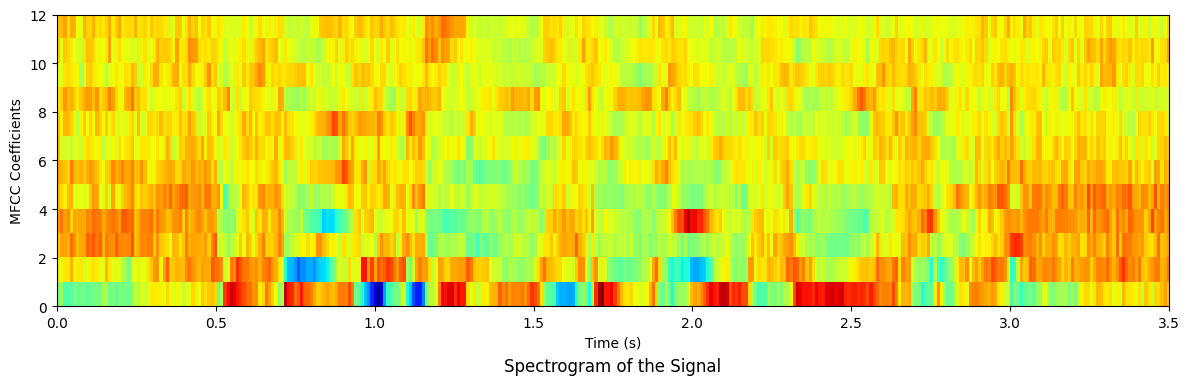

In [77]:
mfcc -= (np.mean(mfcc, axis=0) + 1e-8)
plot_spectrogram(mfcc, sample_rate, is_mfcc=True)